In [1]:
import blue_ml
from blue_ml import ModelSkillAssessor

# Prepare input data

Features and targets are saved in a structured `Timeseries` containing **features** and **targets**.

The Timeseries structure is preserved throughout the workflow and
supports interoperability across all included libraries.

In [2]:
# Load example dataset from Waterbench
# Drop the 'peak_wave_period' feature - we only want to work with 'significant_wave_height' for this example.
timeseries = blue_ml.datasets.load('Europlatform2').drop('peak_wave_period')
timeseries

<blue_ml.Timeseries> Size: 1MB
Dimensions:                             (time: 17070)
Coordinates:
  * time                                (time) datetime64[ns] 137kB 2022-01-0...
Features:
    U                                   (time) float64 137kB 4.501 ... 11.09
    V                                   (time) float64 137kB 4.793 ... 9.981
    Mean Sea Level Pressure             (time) float64 137kB 1.021e+03 ... 994.4
    Europlatform2: Sign. Wave Height    (time) float64 137kB 0.0 ... 3.638
    Europlatform2: Peak Wave Period     (time) float64 137kB nan 1.147 ... 8.425
    Europlatform2: Wave Period, T02     (time) float64 137kB nan ... 5.671
    Europlatform2: Mean Wave Direction  (time) float64 137kB nan 218.7 ... 229.6
Targets:
    significant_wave_height             (time) float64 137kB 1.16 1.15 ... 2.86

We will seperate the training and testing data. The training data itself will be split into training and validation data by the `ModelFrame` during training. The test data will be used for final evaluation of the model performance, and is not used during training in any way.

In [3]:
timeseries_train, timeseries_test = blue_ml.timeseries.operations.train_test_split(timeseries, train_size=0.8)

# Setup Model

Model setup, training, and testing can be performed within a `ModelFrame` structure. The framework automatically handles the splitting of training, validation, and testing data, and ensures that pre‑ and post‑processing steps are applied in the correct order.

<img src="modelframe.png" width="800">

Setup the individual components of the `ModelFrame`

In [4]:
model = blue_ml.machinelearning.architectures.BlueDense().add_single(64,activation='gelu').add_final('linear')
pre_transforms = blue_ml.BluePipeline([
    ('lag', blue_ml.transforms.IncludeLaggedFeatures(lags=[-6, -5, -4, -3, -2, -1],items=timeseries.features.names)),
    ('dir2uv',  blue_ml.transforms.DecomposeDirections(units='deg',items=['Europlatform2: Mean Wave Direction'])),
    ('time_as_feature',  blue_ml.transforms.TimeAsFeature(period='24h')),
    ('dropna',  blue_ml.transforms.DropNaN()),
])
scaler= blue_ml.transforms.StandardScaler()


Setup the `ModelFrame`

In [5]:
model_frame = (
    blue_ml.ModelFrame("Demo ML Framework")
    .add_model(model)
    .add_pre_transforms(pre_transforms)
    .add_scaler(scaler)
) 

# Fit and evaluate 
model_skill: ModelSkillAssessor = model_frame.fit_evaluate(timeseries_train, epochs=5, ts_baseline=timeseries_train['Europlatform2: Sign. Wave Height'])

Epoch 1/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2388 - mean_absolute_error: 0.3498
Epoch 2/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1557 - mean_absolute_error: 0.2661
Epoch 3/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0741 - mean_absolute_error: 0.2038
Epoch 4/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0731 - mean_absolute_error: 0.2009
Epoch 5/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0720 - mean_absolute_error: 0.1991
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


[<Axes: title={'center': 'Baseline vs Target'}, xlabel='Observation,  []', ylabel='Model,  []'>,
 <Axes: title={'center': 'Demo ML Framework vs Target'}, xlabel='Observation,  []', ylabel='Model,  []'>]

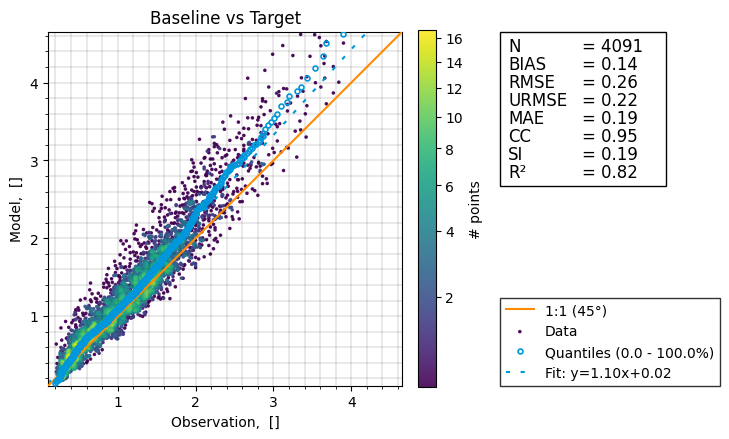

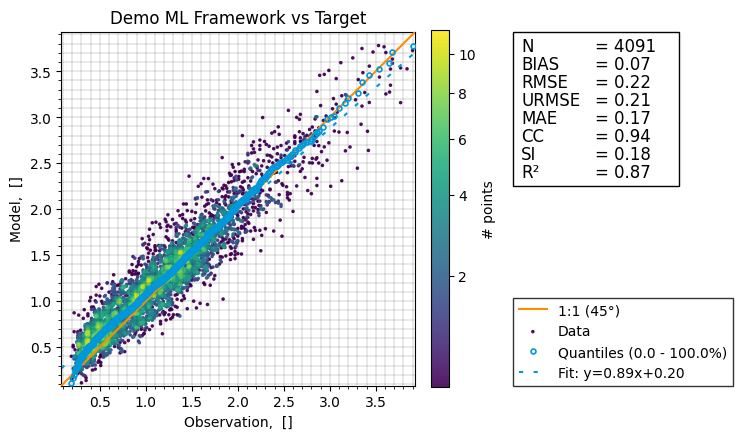

In [6]:
model_skill.plot_scatter()

In [7]:
model_skill.skill_table()

,,n,bias,rmse,urmse,mae,cc,si,r2
model,observation,,,,,,,,
Baseline,Target,4091,+0.140,0.264,0.224,0.187,0.953,0.191,0.817
Demo ML Framework,Target,4091,+0.072,0.222,0.210,0.174,0.941,0.179,0.871


# Operationalise

## Saving the trained setup
Each of the individual framework elements are accessible and can be exported.

In [8]:
model_frame.model.write("model.zip")
model_frame.scaler.write("scaler.zip")
model_frame.pre_transforms.write("pre_transforms.zip")

## Production mode
For production use, the components are loaded back in to create a new ModelFrame instance, which can be used for prediction on new data.

## Load

In [9]:
# Read the individual components back in
model = blue_ml.machinelearning.read("model.zip")
scaler = blue_ml.transforms.read("scaler.zip")
pre_transforms = blue_ml.BluePipeline.read("pre_transforms.zip")

# Create a new ModelFrame with the loaded components
model_frame = blue_ml.ModelFrame("Demo Production Model", model=model,scaler=scaler, pre_transforms=pre_transforms)

## Apply

In [10]:
timeseries_predict = model_frame.predict(timeseries_test)

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


From here it is up to the user to decide what to do with the data.

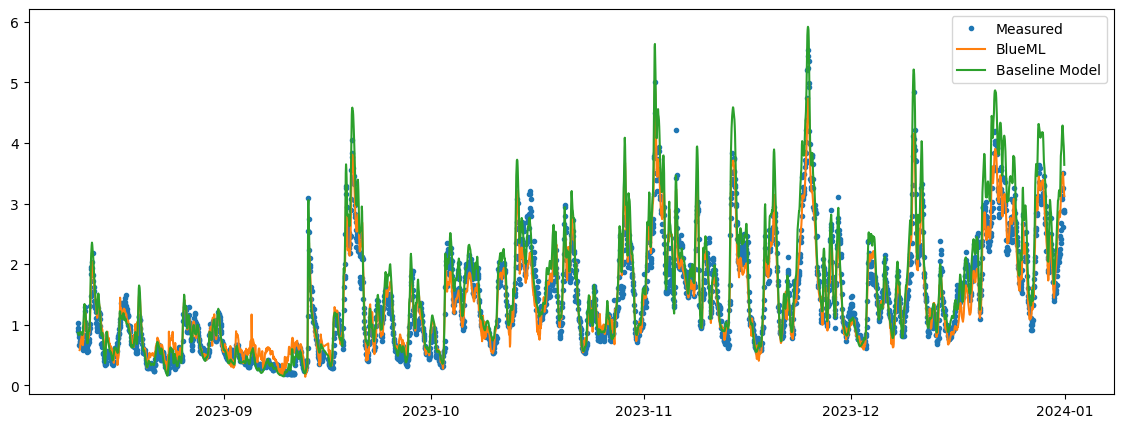

In [11]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(14, 5))
plt.plot(timeseries_test.time, timeseries_test['significant_wave_height'], label='Measured',ls='none',marker='.')
plt.plot(timeseries_predict.time, timeseries_predict['significant_wave_height'], label='BlueML')
plt.plot(timeseries_test.time, timeseries_test['Europlatform2: Sign. Wave Height'], label='Baseline Model')
plt.legend()
plt.show()